Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [9]:
df = pd.read_csv("/content/student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Understand Data

In [11]:
print(df.columns)
df.info()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null 

Check Missing Values

In [12]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


**Exploratory Data Analysis (EDA)**
1. Grade Distribution

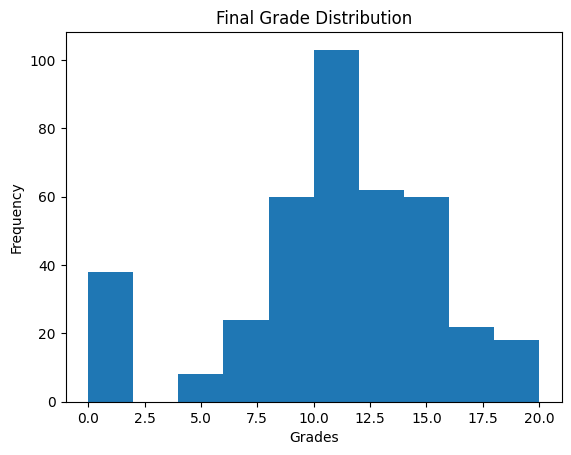

In [13]:
plt.hist(df['G3'])
plt.title("Final Grade Distribution")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

2. Study Time vs Grade

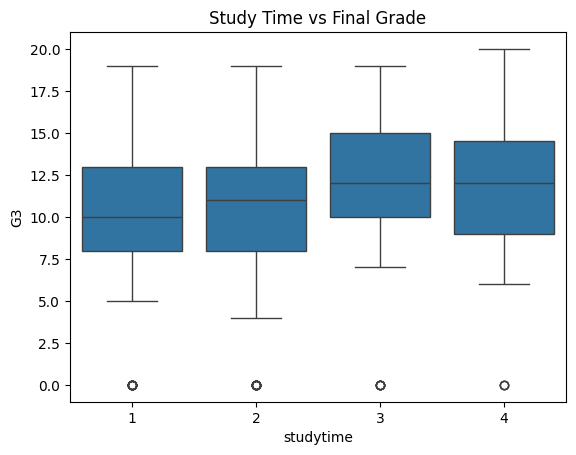

In [14]:
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Final Grade")
plt.show()

3. Correlation Heatmap

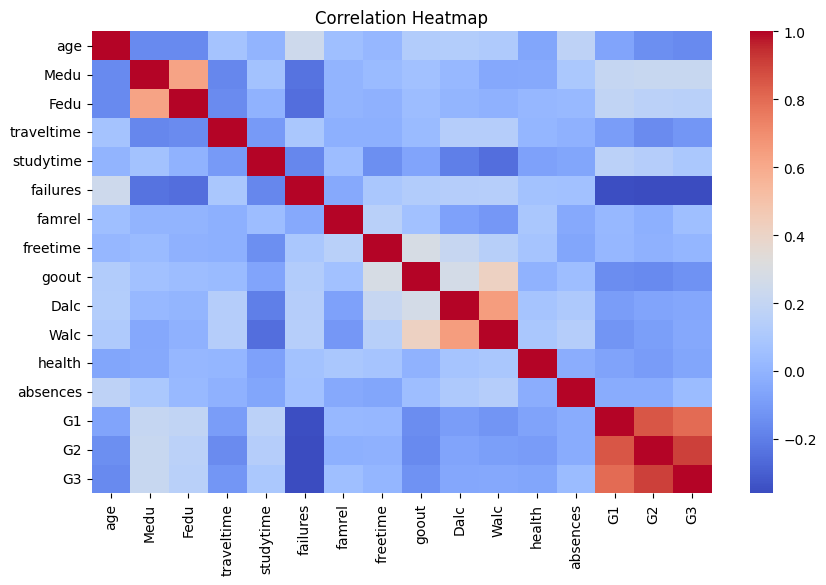

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Data Preprocessing

In [16]:
df = pd.get_dummies(df, drop_first=True)

Feature Selection

In [17]:
X = df.drop('G3', axis=1)
y = df['G3']

Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model 1 — Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Model 2 — KNN

In [20]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

Evaluation

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

print("\nKNN:")
print("MSE:", mean_squared_error(y_test, knn_pred))
print("R2 Score:", r2_score(y_test, knn_pred))

Linear Regression:
MSE: 5.656642833231222
R2 Score: 0.7241341236974022

KNN:
MSE: 4.9473417721518995
R2 Score: 0.7587256587378489


Model Comparison Graph

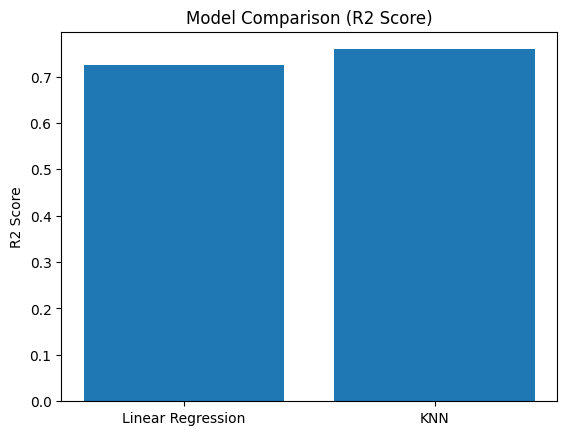

In [22]:
models = ['Linear Regression', 'KNN']
r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, knn_pred)
]

plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

Prediction Example

In [23]:
sample = X_test.iloc[0:1]

print("Actual:", y_test.iloc[0])
print("Predicted (LR):", lr.predict(sample))
print("Predicted (KNN):", knn.predict(sample))

Actual: 10
Predicted (LR): [6.00160699]
Predicted (KNN): [3.8]
